# GPROF-IR

This notebooks evaluates the operational version of the GPROF-IR retrieval on the SatRain benchmark dataset. This notebook requires the ``gprof_ir`` package to be installed.

## The Retrieval Callback

The ``gprof_ir`` package provides a direct interface to run the GPROF-IR retrieval on the SatRain data. For the baseline results, we run the configuration GPROF-IR (GMI, 3) configuration that is used for operational processing.

In [1]:
from gprof_ir.satrain import GPROFIRRetrieval

ir_input_data = ["/edata2/simon/satellite_data/gpm/merged_ir/"]

gprof_ir_retrieval = GPROFIRRetrieval(
    ir_input_data,
    variant="gmi",
    n_steps=3,
    device="cuda:0",
    dtype="bfloat16"
)

## Case Study

In [2]:
from satrain.target import TargetConfig
from satrain.evaluation import Evaluator

target_config = TargetConfig(min_rqi=0.5)
evaluator = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[],
    download=True,
    target_config=target_config,
)

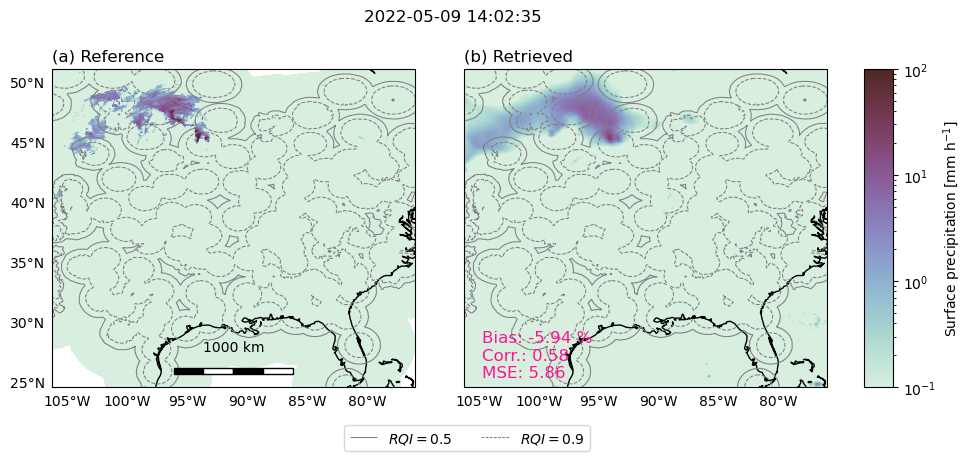

In [3]:
fig = evaluator.plot_retrieval_results(1016, gprof_ir_retrieval, include_metrics=True, )

## Evaluation

In [ ]:
import logging
LOGGER = logging.getLogger("evaluation")
    
results = []
domains = ["austria", "conus", "korea"]
base_sensors = ["atms", "gmi"]

for sensor in base_sensors:
    for domain in domains:
        LOGGER.info("Running evaluation for domain '%s'.", domain)
        evaluator = Evaluator(
            domain=domain,
            base_sensor=sensor,
            geometry="gridded",
            retrieval_input=[],
            download=True,
            target_config=target_config,
        )
        evaluator.evaluate(
            gprof_ir_retrieval,
            n_processes=1
        )
        res = evaluator.get_results()
        results.append(res)
        res.to_netcdf(f"gprof_ir_{sensor}_{domain}.nc")

INFO     Running evaluation for domain 'austria'.

Output()

ERROR    Encountered an error when loading input data.                                                             
         Traceback (most recent call last):                                                                        
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/pytorch_retrieve/inference.py", line 
         1150, in run                                                                                              
             input_data = next(input_iterator)                                                                     
                          ^^^^^^^^^^^^^^^^^^^^                                                                     
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/gprof_ir/retrieval.py", line 396, in 
         __iter__                                                                                                  
             yield self.load_input(path)                                                                           
                   ^^^^^^^^^^^^^^^^^^^^^                                                                           
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/gprof_ir/retrieval.py", line 355, in 
         load_input                                                                                                
             input_data = load_ir_tbs_multi_step(                                                                  
                          ^^^^^^^^^^^^^^^^^^^^^^^                                                                  
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/gprof_ir/retrieval.py", line 206, in 
         load_ir_tbs_multi_step                                                                                    
             data.append(load_input_data(path, input_format=input_format, slices=slices))                          
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                           
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/gprof_ir/retrieval.py", line 58, in  
         load_input_data                                                                                           
             with xr.open_dataset(path) as data:                                                                   
                  ^^^^^^^^^^^^^^^^^^^^^                                                                            
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/xarray/backends/api.py", line 652, in
         open_dataset                                                                                              
             engine = plugins.guess_engine(filename_or_obj)                                                        
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                                        
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/xarray/backends/plugins.py", line    
         194, in guess_engine                                                                                      
             raise ValueError(error_msg)                                                                           
         ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4',           
         'h5netcdf', 'scipy', 'cfgrib', 'zarr']. Consider explicitly selecting one of the installed engines via the
         ``engine`` parameter, or installing additional IO dependencies, see:                                      
         https://docs.xarray.dev/en/stable/getting-started-guide/installing.html                                   
         https://docs.xarray.dev/en/stable/user-guide/io.html

ERROR    Encountered an error when processing scene 848.                                                           
         Traceback (most recent call last):                                                                        
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1304, in evaluate                        
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1227, in evaluate_scene                  
             return evaluate_scene(                                                                                
                    ^^^^^^^^^^^^^^^                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 582, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
                       ^^^^^^^^^^^^^^^^^^^^^^                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 397, in process_scene_spatial            
             vars_retrieved = process(                                                                             
                              ^^^^^^^^                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 166, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
                         ^^^^^^^^^^^^^^^^^^^^^^^^                                                                  
           File "/gdata1/simon/.conda/envs/chimp/lib/python3.12/site-packages/gprof_ir/satrain.py", line 185, in   
         __call__                                                                                                  
             run_retrieval_multi(                                                                                  
         IndexError: list index out of range

INFO     Running evaluation for domain 'conus'.

Output()